#Credit Risk Assessment

## 1. Load the Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21,9600,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23,65500,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24,54400,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0


## 2. Exploratory Data Analysis (EDA)
- Here we simply look at the data before touching it.
- We want to understand it first, then work on it.

In [4]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19083 entries, 0 to 19082
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19083 non-null  int64  
 1   person_income               19083 non-null  int64  
 2   person_home_ownership       19083 non-null  object 
 3   person_emp_length           18522 non-null  float64
 4   loan_intent                 19083 non-null  object 
 5   loan_grade                  19082 non-null  object 
 6   loan_amnt                   19082 non-null  float64
 7   loan_int_rate               17288 non-null  float64
 8   loan_status                 19082 non-null  float64
 9   loan_percent_income         19082 non-null  float64
 10  cb_person_default_on_file   19082 non-null  object 
 11  cb_person_cred_hist_length  19082 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.7+ MB
None


There are 32481 entries and 12 features

### Missing values


In [5]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,561
loan_intent,0
loan_grade,1
loan_amnt,1
loan_int_rate,1795
loan_status,1
loan_percent_income,1


In [6]:
df[df['person_emp_length'].isnull()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000.0,5.42,1.0,0.16,N,4.0
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000.0,12.42,0.0,0.19,N,2.0
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900.0,NaN,1.0,0.23,N,3.0
407,25,52000,RENT,NaN,PERSONAL,B,24000.0,10.74,1.0,0.46,N,2.0
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250.0,15.27,0.0,0.13,Y,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
18974,28,30000,MORTGAGE,NaN,VENTURE,A,6000.0,6.03,0.0,0.20,N,8.0
18975,31,30000,MORTGAGE,NaN,EDUCATION,B,1200.0,NaN,0.0,0.04,N,8.0
18989,28,30000,MORTGAGE,NaN,MEDICAL,A,4750.0,7.90,0.0,0.16,N,7.0
19034,31,30000,MORTGAGE,NaN,VENTURE,A,5000.0,NaN,0.0,0.17,N,7.0


In [7]:
df[df['loan_int_rate'].isnull()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000.0,NaN,1.0,0.42,N,4.0
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000.0,NaN,1.0,0.38,Y,4.0
57,23,277000,OWN,3.0,PERSONAL,A,35000.0,NaN,0.0,0.13,N,4.0
59,24,12000,OWN,2.0,VENTURE,E,1750.0,NaN,0.0,0.15,Y,3.0
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000.0,NaN,1.0,0.04,N,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19065,29,31632,RENT,2.0,PERSONAL,B,2100.0,NaN,0.0,0.07,N,6.0
19068,27,39000,RENT,3.0,DEBTCONSOLIDATION,B,2100.0,NaN,0.0,0.05,N,6.0
19069,32,51996,RENT,6.0,MEDICAL,C,2100.0,NaN,0.0,0.04,Y,7.0
19078,28,33600,RENT,9.0,EDUCATION,C,14000.0,NaN,1.0,0.42,Y,5.0


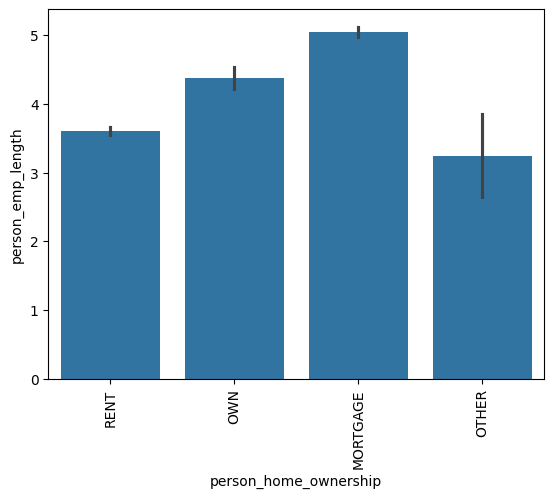

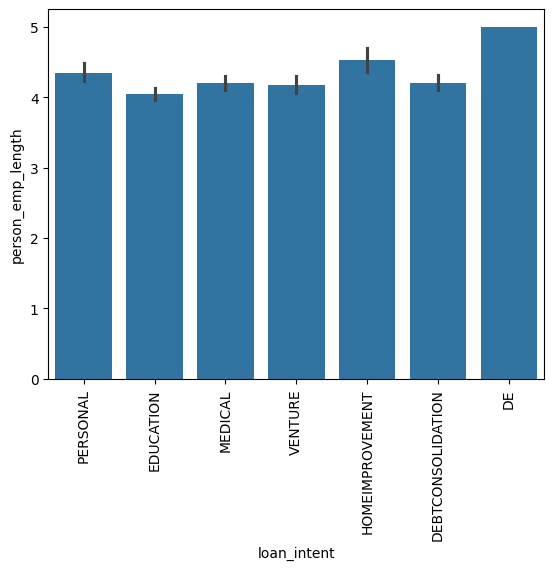

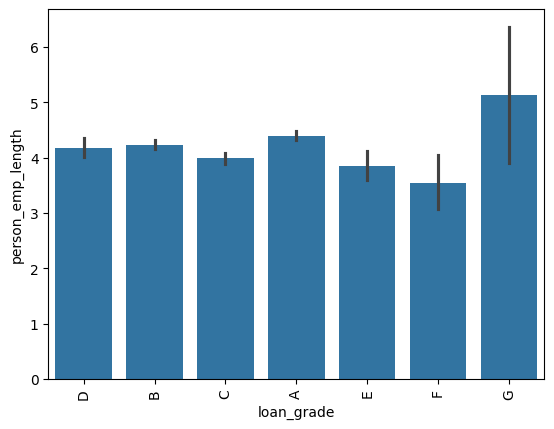

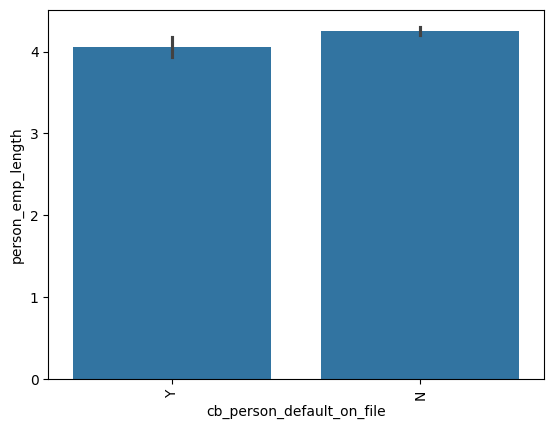

In [19]:
cat = df.select_dtypes(include=['object']).columns

for i in cat:
    sns.barplot(data=df, y='person_emp_length', x = i)
    plt.xticks(rotation=90)
    plt.show()

In [15]:
for i in cat:
    percentage_null = df.groupby(i)['person_emp_length'].apply(
        lambda x: x.isna().mean() * 100
    )
    print(percentage_null)

person_home_ownership
MORTGAGE    2.935154
OTHER       0.000000
OWN         7.503320
RENT        2.288802
Name: person_emp_length, dtype: float64
loan_intent
DE                   0.000000
DEBTCONSOLIDATION    2.825040
EDUCATION            2.865727
HOMEIMPROVEMENT      3.218256
MEDICAL              3.078276
PERSONAL             2.736239
VENTURE              3.050044
Name: person_emp_length, dtype: float64
loan_grade
A    4.160000
B    2.784523
C    2.133333
D    1.813110
E    1.027397
F    2.857143
G    0.000000
Name: person_emp_length, dtype: float64
cb_person_default_on_file
N    3.136931
Y    2.020202
Name: person_emp_length, dtype: float64


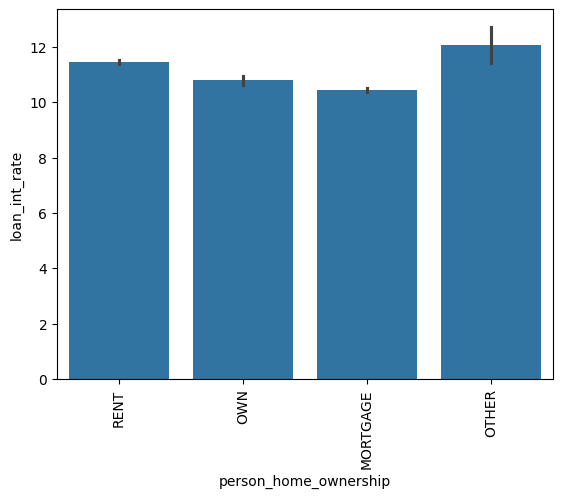

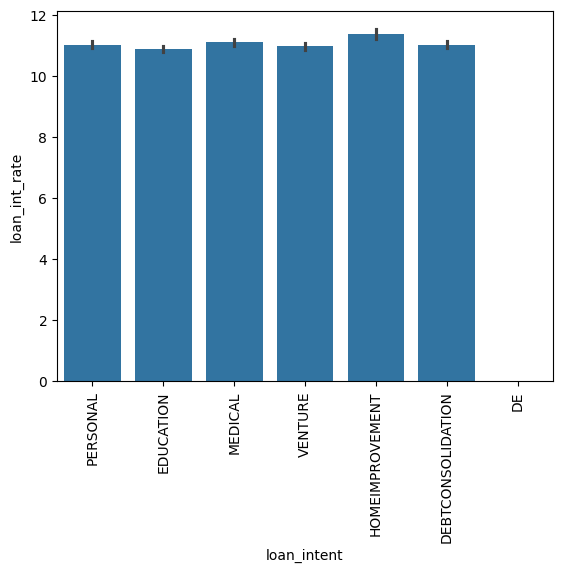

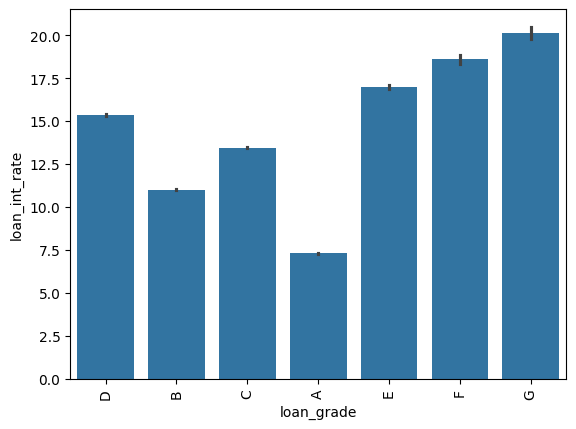

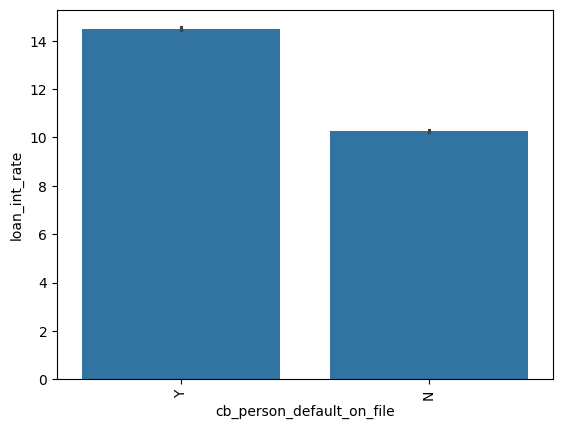

In [22]:
cat = df.select_dtypes(include=['object']).columns

for i in cat:
    sns.barplot(data=df, y='loan_int_rate', x=i)
    plt.xticks(rotation=90)
    plt.show()

In [21]:
for i in cat:
    percentage_null = df.groupby(i)['person_emp_length'].apply(
        lambda x: x.isna().mean() * 100
    )
    print(percentage_null)

person_home_ownership
MORTGAGE    2.935154
OTHER       0.000000
OWN         7.503320
RENT        2.288802
Name: person_emp_length, dtype: float64
loan_intent
DE                   0.000000
DEBTCONSOLIDATION    2.825040
EDUCATION            2.865727
HOMEIMPROVEMENT      3.218256
MEDICAL              3.078276
PERSONAL             2.736239
VENTURE              3.050044
Name: person_emp_length, dtype: float64
loan_grade
A    4.160000
B    2.784523
C    2.133333
D    1.813110
E    1.027397
F    2.857143
G    0.000000
Name: person_emp_length, dtype: float64
cb_person_default_on_file
N    3.136931
Y    2.020202
Name: person_emp_length, dtype: float64


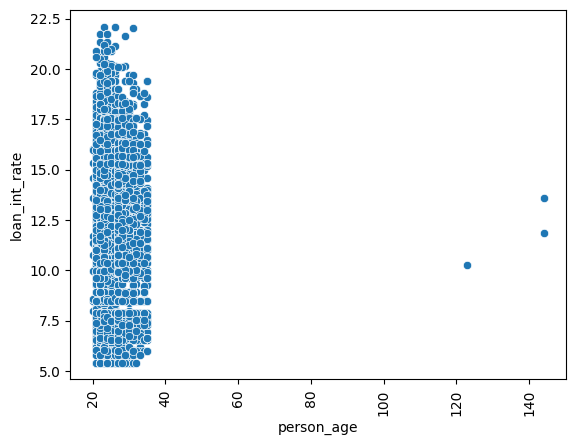

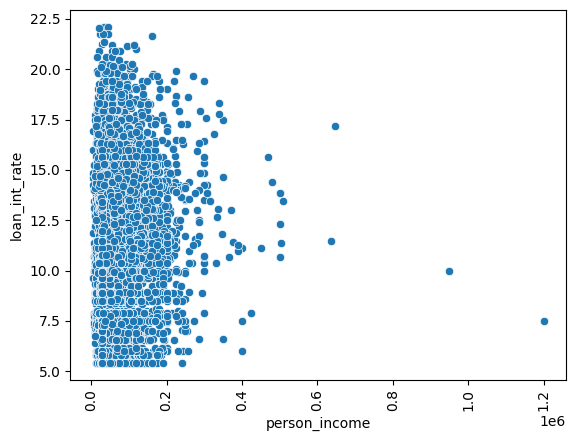

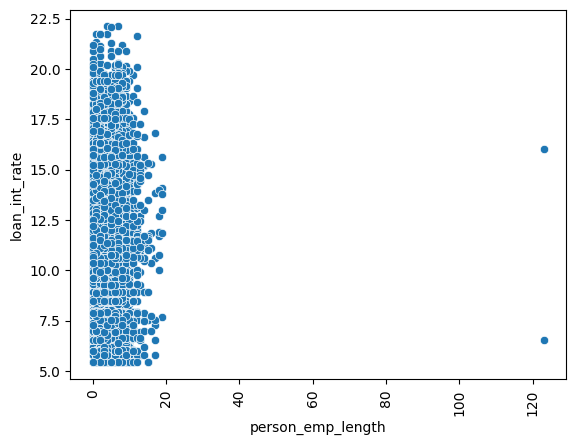

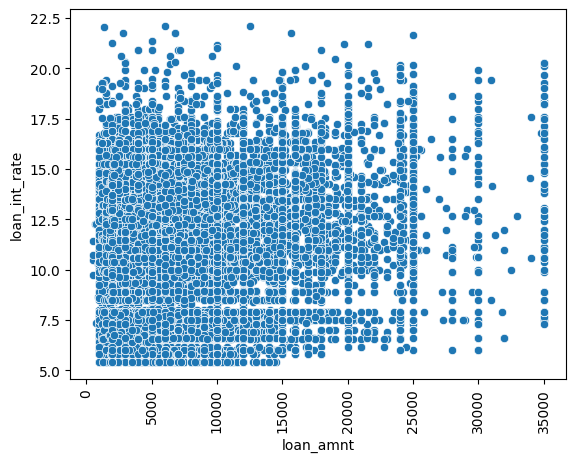

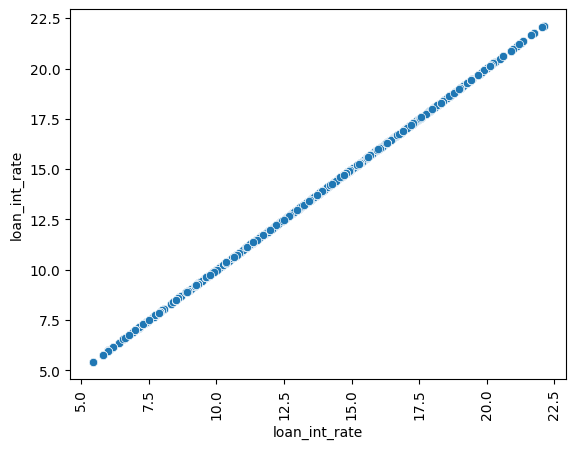

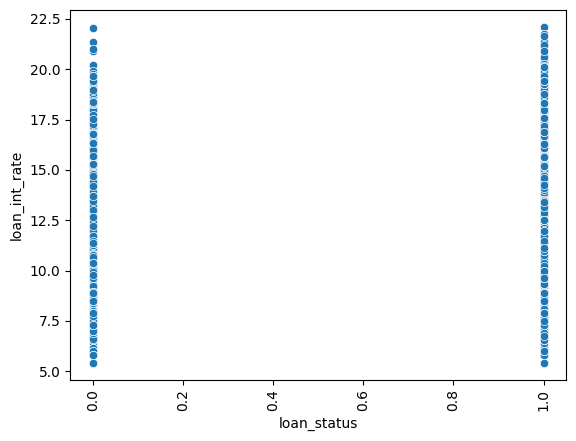

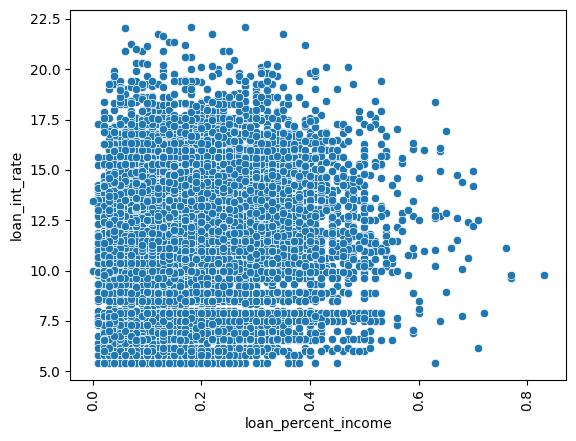

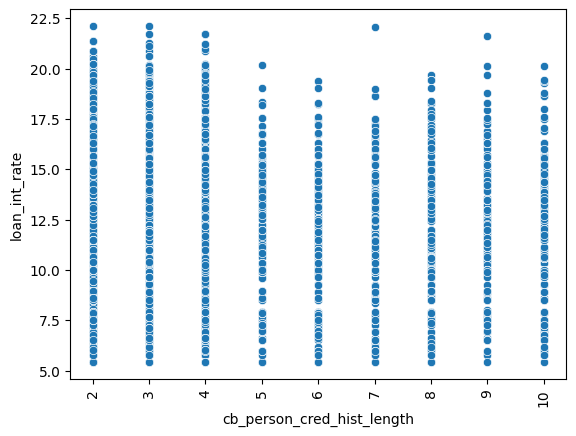

In [26]:
for i in num:
    sns.scatterplot(data=df, y='loan_int_rate', x=i)
    plt.xticks(rotation=90)
    plt.show()

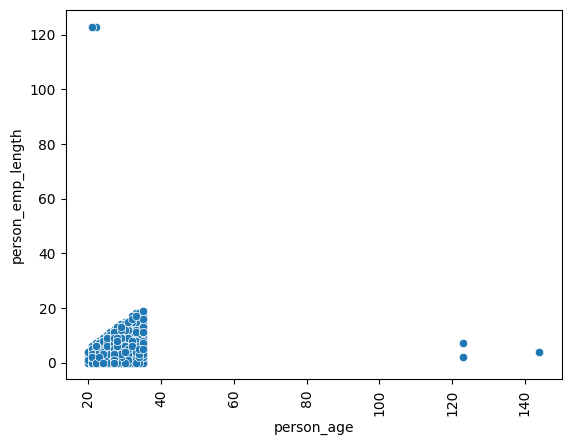

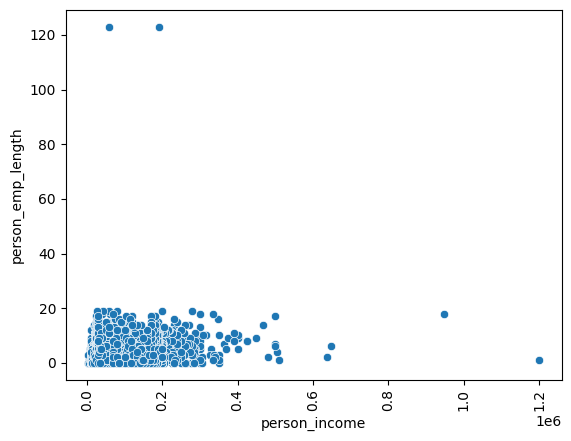

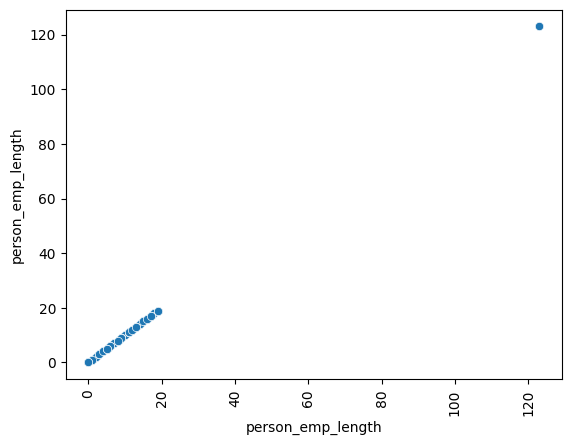

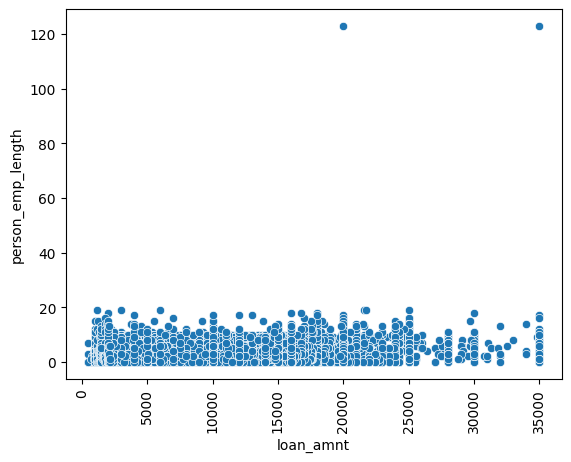

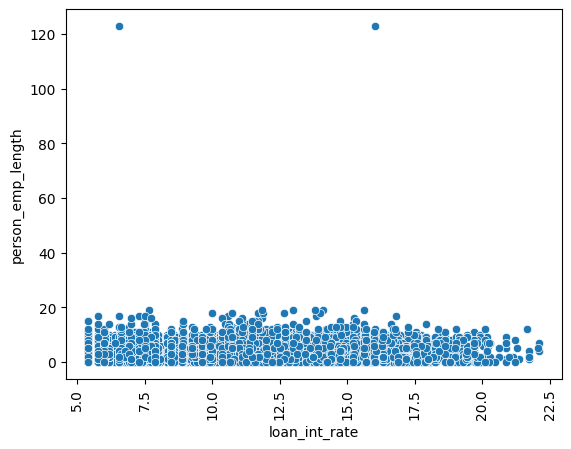

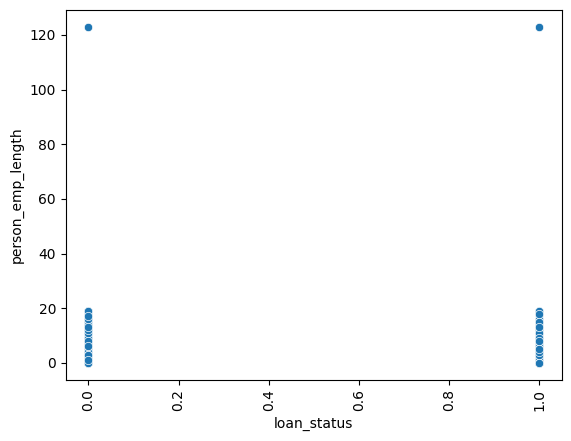

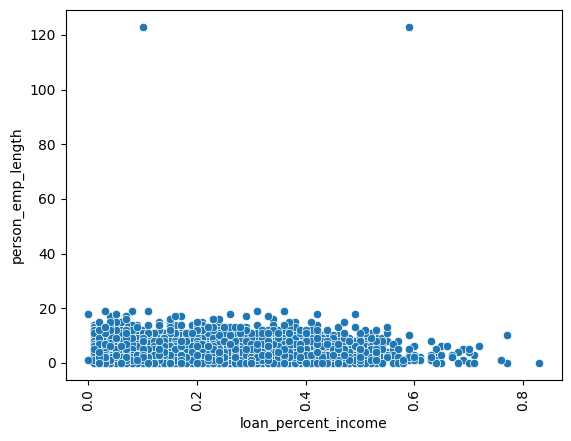

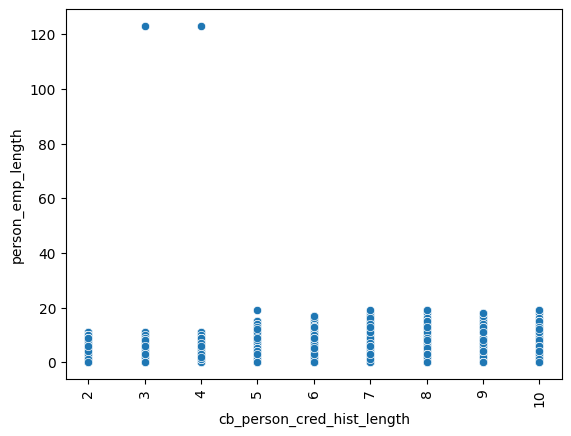

In [27]:
for i in num:
    sns.scatterplot(data=df, y='person_emp_length', x=i)
    plt.xticks(rotation=90)
    plt.show()

Two features **person_emp_length** and **loan_int_rate** have

missing values

There does not appear any significant relation between null columns and other columns

### Target balance
- Check how many people defaulted vs how many repaid.
- This tells us if our data is balanced or imbalanced.

In [30]:
df.head()
df['loan_status'].unique()

df['loan_status'].value_counts()

,count
loan_status,
0.0,14578
1.0,4504


<Axes: xlabel='loan_status', ylabel='count'>

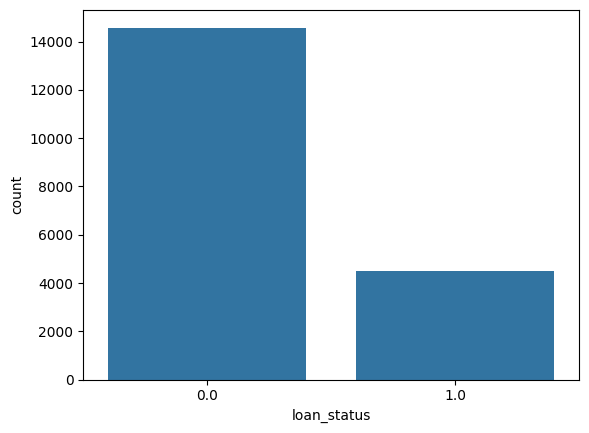

In [31]:
sns.countplot(x='loan_status', data=df)

### Outlier check
- Look for values that seem impossible, like age 144.
- These are signs of bad data entries.

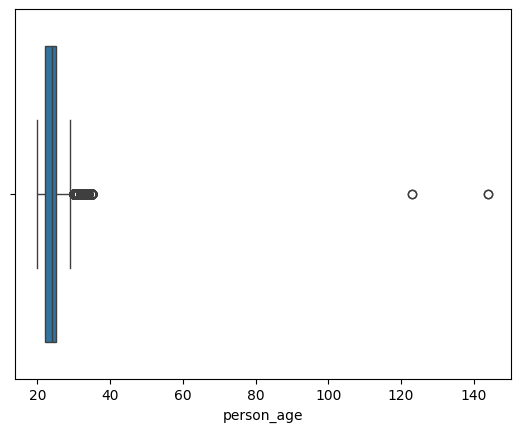

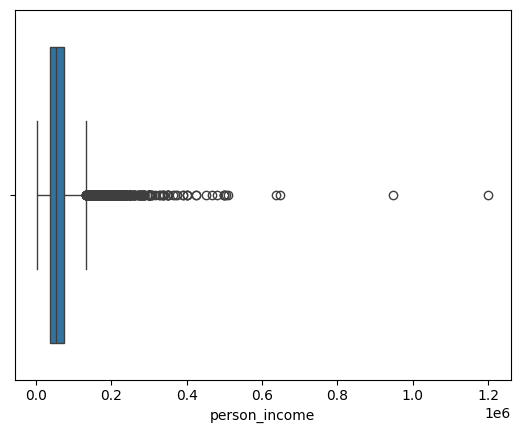

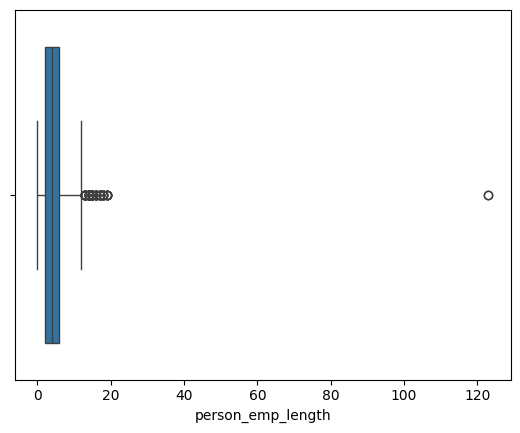

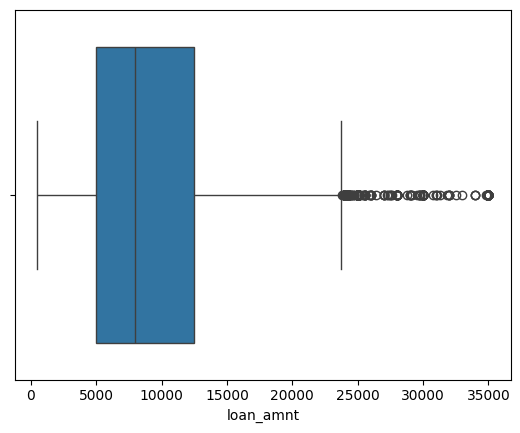

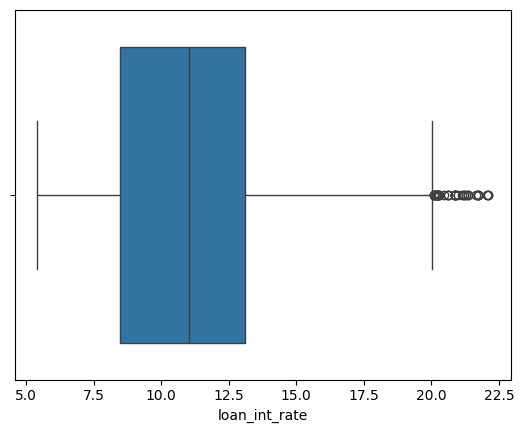

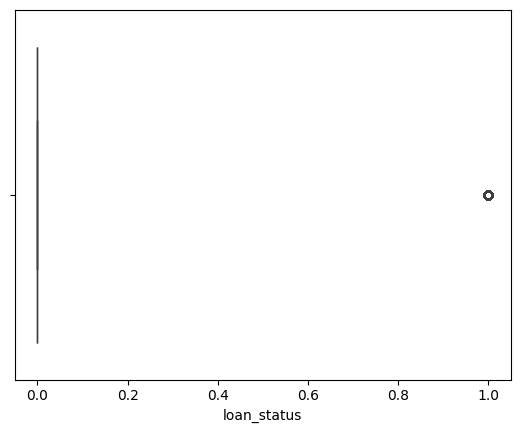

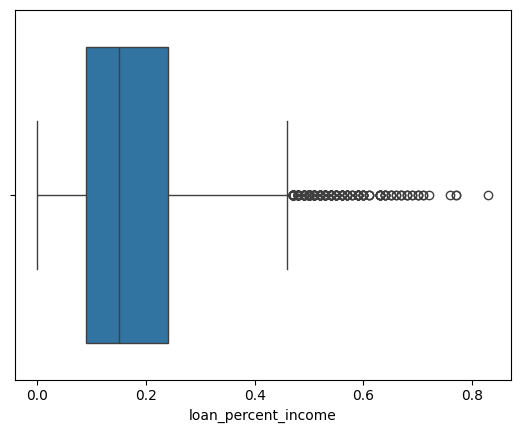

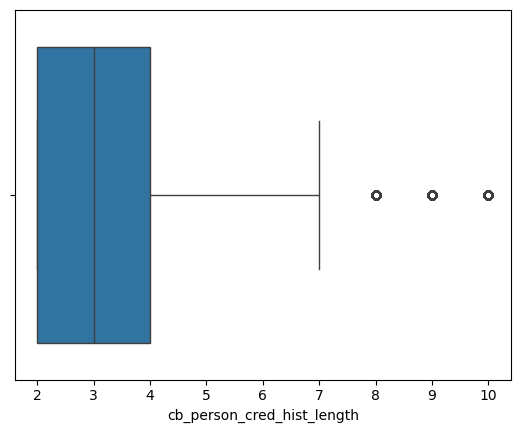

In [32]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [33]:
(df['person_age'] > 100).sum()

np.int64(4)

In [34]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [35]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,19083.000000,1.908300e+04,19083.000000,19082.000000,19083.000000,19082.000000,19082.000000,19082.000000
mean,24.062307,6.220968e+04,4.213314,9587.479038,11.018222,0.236034,0.175593,3.292999
std,2.761612,4.085170e+04,3.231586,6469.782076,3.077248,0.424654,0.109805,1.434393
min,20.000000,4.080000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,22.000000,3.626300e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,2.000000
50%,24.000000,5.400000e+04,4.000000,8000.000000,11.018222,0.000000,0.150000,3.000000
75%,25.000000,7.500000e+04,6.000000,12500.000000,13.110000,0.000000,0.240000,4.000000
max,144.000000,1.200000e+06,123.000000,35000.000000,22.110000,1.000000,0.830000,10.000000


### Correlation check

<Axes: >

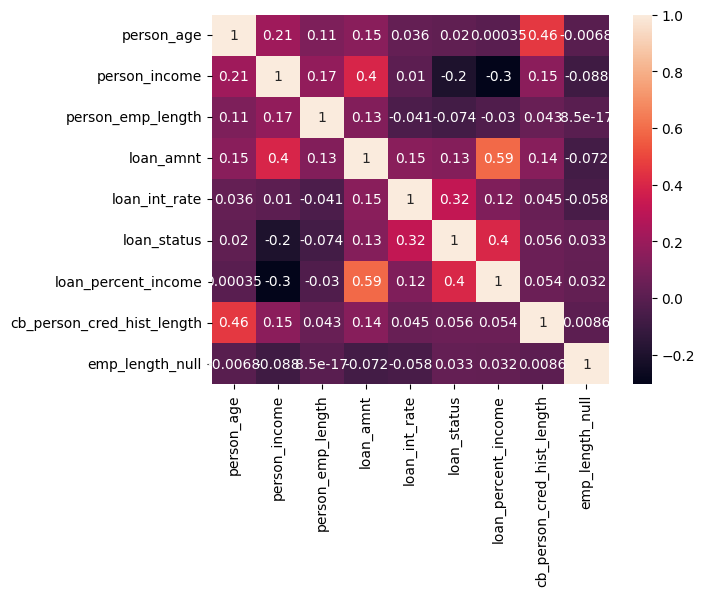

In [36]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

**person_age** and **cb_person_cred_hist_length** are strongly correlated

/tmp/ipykernel_2127/3659189263.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_cols_hist[col], color='forestgreen',
/tmp/ipykernel_2127/3659189263.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_cols_hist[col], color='forestgreen',
/tmp/ipykernel_2127/3659189263.py:8: UserWarning

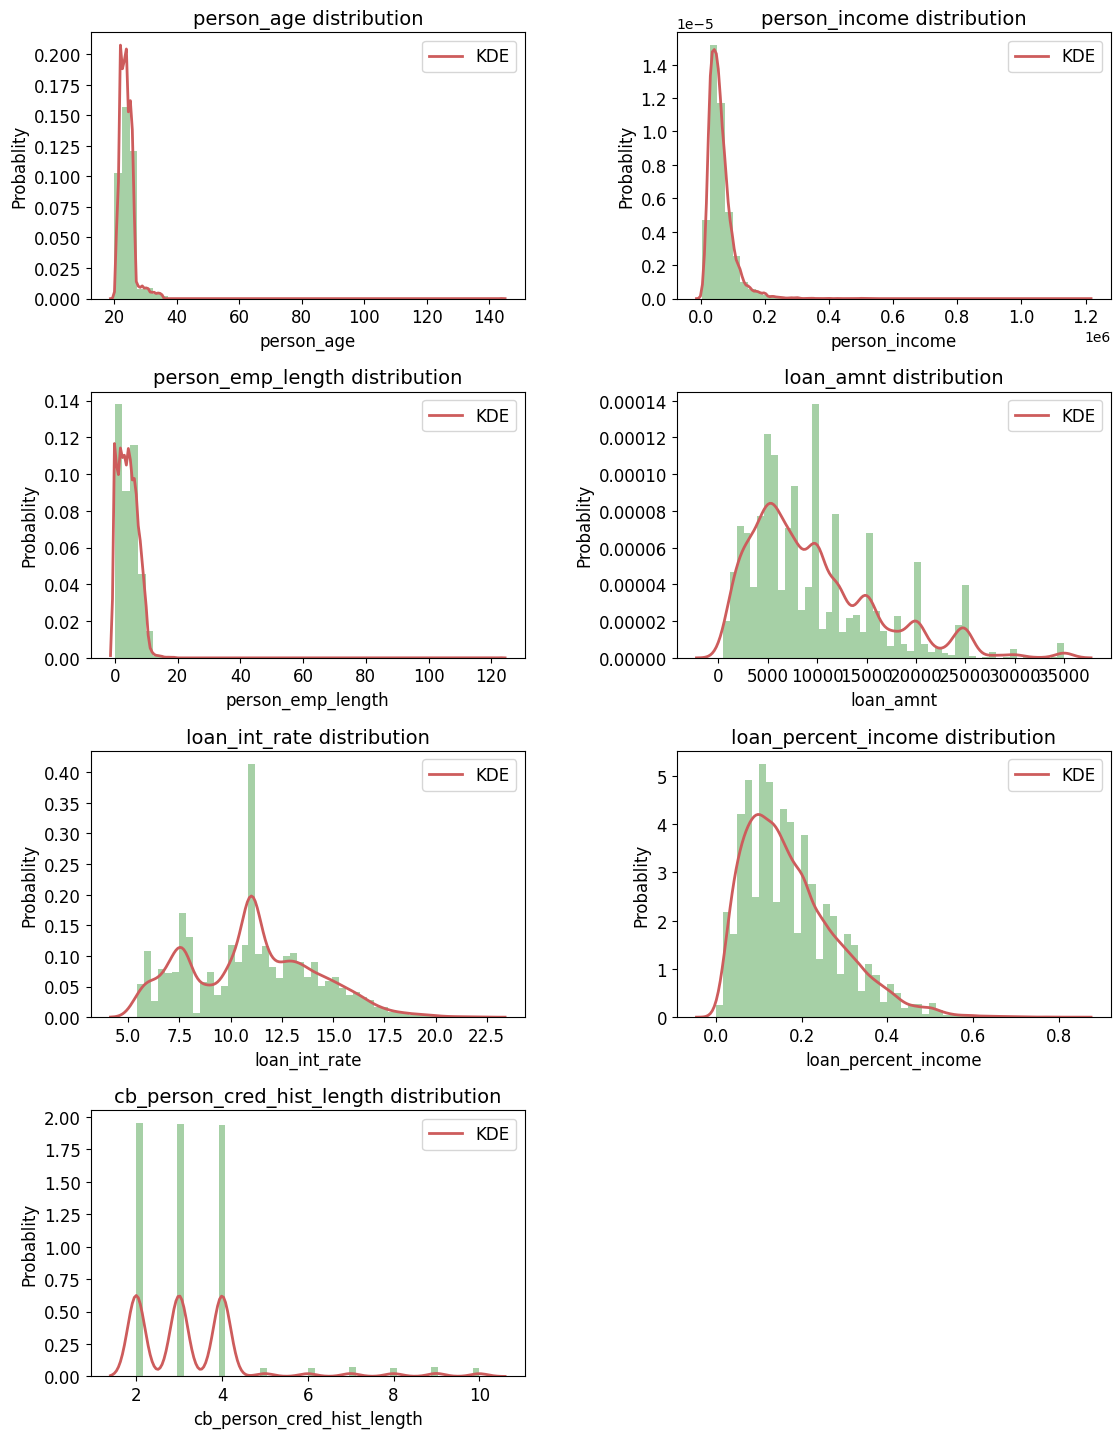

In [37]:
num_cols = pd.DataFrame(df[df.select_dtypes(include=['float', 'int']).columns])
num_cols_hist = num_cols.drop(['loan_status'], axis=1)
plt.figure(figsize=(12,16))

for i, col in enumerate(num_cols_hist.columns):
    idx = int('42'+ str(i+1))
    plt.subplot(idx)
    sns.distplot(num_cols_hist[col], color='forestgreen',
                 kde_kws={'color': 'indianred', 'lw': 2, 'label': 'KDE'})
    plt.title(col+' distribution', fontsize=14)
    plt.ylabel('Probablity', fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(['KDE'], prop={"size":12})

plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35,
                    wspace=0.35)
plt.show()

All numerical features are right skewed

## 3. Data Validation & Outlier Handling
- Here we clean the data properly.
- We remove duplicate rows.
- We remove rows with an impossible age or work experience.
- We remove the column loan percent income since it is dependent on income and loan amount
- We remove rows with zero or negative income and loan amount.
- We check if the interest rate looks realistic.
- We also flag rows where numbers don't add up correctly.

In [38]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

#Remove loann_percent_income
df_copy = df_copy.drop('loan_percent_income', axis=1)

Original Rows: 19083
Rows after removing duplicates : 18961
Loan intreset rate range from (min: 5.42 and max: 23.22)


## 4. Features, Target & Train-Test Split
- We separate the data into input features and the target.
- The target is whether the applicant defaulted or not.
- We split the data into a training part and a testing part.
- The model learns from the training part only.

In [39]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance
- Very few people actually default in this data.
- If we ignore this, the model may just favor the majority class.
- We give more importance to the minority class during training.
- This helps the model actually learn to spot defaulters.

In [42]:
#0 -> no loan (most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

/tmp/ipykernel_2127/2318607077.py:4: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  neg, pos = np.bincount(y_train)


In [43]:
scale_weigths

np.float64(3.2178025034770514)

## 6. Data Preprocessing — Pipelines & Column Transformer
- Raw data is not ready for a model directly.
- We need to prepare numeric and text columns differently.
- We will build a Pipeline for each model.
- We will use ColumnTransformer to apply different steps to different columns.

### Preprocessing for Logistic Regression
- Fill missing numeric values.
- Scale numeric values, since this model is sensitive to scale.
- Convert category columns into numbers using one-hot encoding.

In [45]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
        ]), categorical_cols)
    ])


### Preprocessing for Random Forest
- Fill missing numeric values.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [66]:
#RandomForest: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_rf = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

### Preprocessing for XGBoost
- imputatiing missing numeric values not needed.
- No scaling needed here, since tree models don't need it.
- Convert category columns into numbers using one-hot encoding.

In [67]:
#XGBoost: Only One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


## 7. Evaluation Helper Function
- We build one common function to check any model's performance.
- It will show accuracy, precision, recall, F1 score, and more.
- It will also show a confusion matrix and a precision-recall curve.

In [68]:
#We have to evaluate Logistic Model, Random Forest and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

## 9. Model Training
- We start with a simple model first.
- This becomes our benchmark to beat.
- We train it and check its score on the test data and train other models

In [72]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [ ]:
#Evaluate the Logistic Model.

Baseline Logistic Model Metrics:
Accuracy : 0.80
Precision : 0.55
Recall : 0.80
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.80      0.86      2892
         1.0       0.55      0.80      0.65       899

    accuracy                           0.80      3791
   macro avg       0.74      0.80      0.75      3791
weighted avg       0.84      0.80      0.81      3791



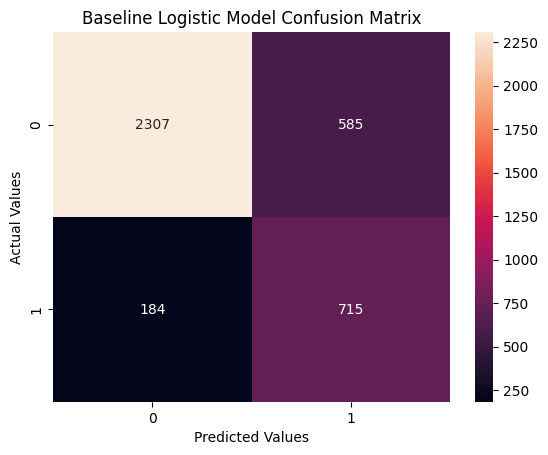

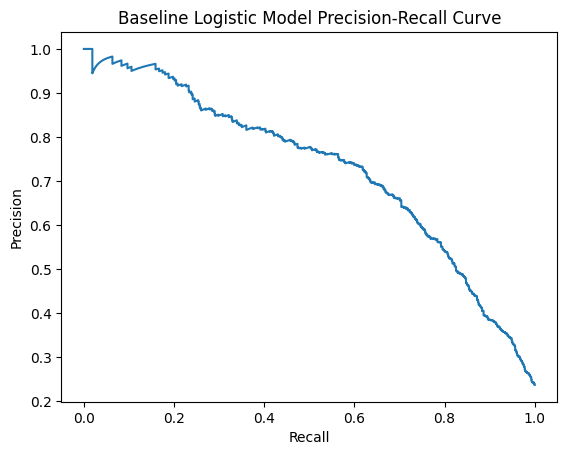

In [73]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

In [74]:
rf_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(class_weight= "balanced"))
])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

Random Forest Model Metrics:
Accuracy : 0.91
Precision : 0.92
Recall : 0.70
F1 : 0.79

Random Forest Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.95      2892
         1.0       0.92      0.70      0.79       899

    accuracy                           0.91      3791
   macro avg       0.92      0.84      0.87      3791
weighted avg       0.91      0.91      0.91      3791



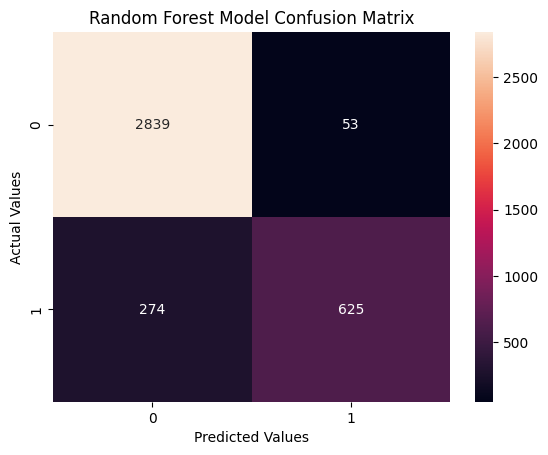

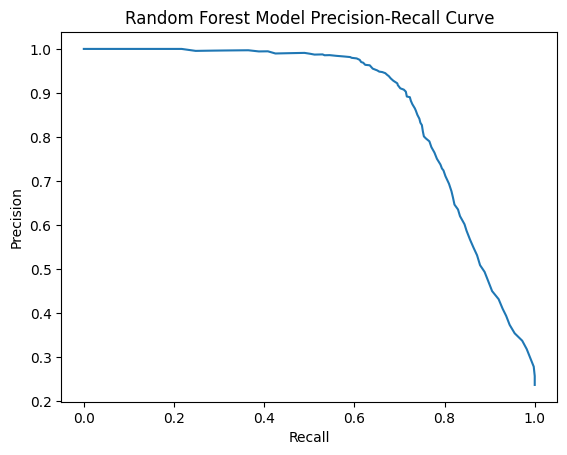

In [75]:
evaluate_model("Random Forest Model", rf_model ,X_test, y_test)

In [76]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Model Metrics:
Accuracy : 0.74
Precision : 0.47
Recall : 0.65
F1 : 0.55

XGBoost Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.77      0.82      2892
         1.0       0.47      0.65      0.55       899

    accuracy                           0.74      3791
   macro avg       0.67      0.71      0.68      3791
weighted avg       0.78      0.74      0.76      3791



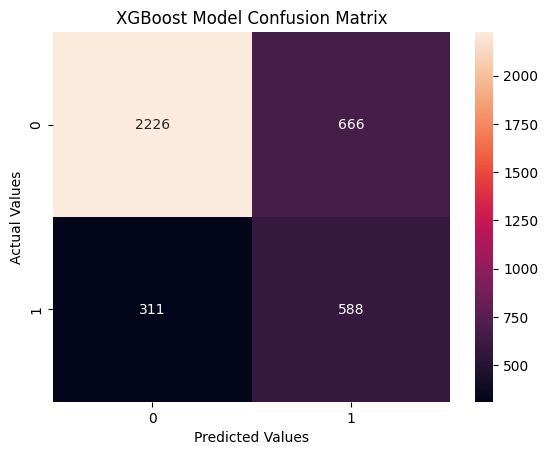

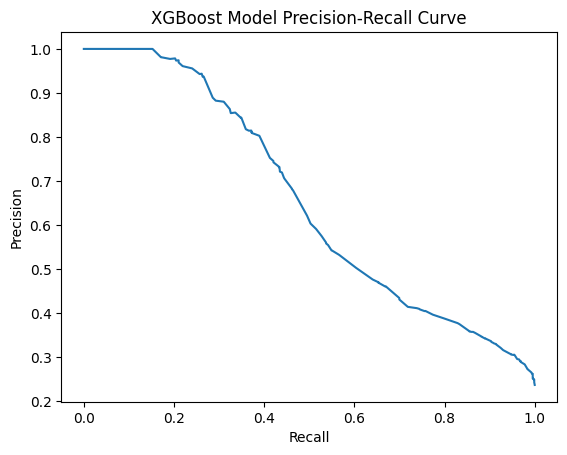

In [77]:
evaluate_model("XGBoost Model", xg_model ,X_test, y_test)

Using Smote for imbalance

In [80]:
from imblearn.over_sampling import SMOTENC

# Find categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print("Categorical columns:")
print(categorical_cols)

# Get their column positions
categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_cols
]

print("Categorical indices:")
print(categorical_indices)

# Apply SMOTENC
smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check class distribution
print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Categorical columns:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')
Categorical indices:
[2, 4, 5, 8]

Before SMOTE:
loan_status
0.0    11568
1.0     3595
Name: count, dtype: int64

After SMOTE:
loan_status
0.0    11568
1.0    11568
Name: count, dtype: int64


In [86]:
baseline_model_smote = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000))
])

baseline_model_smote.fit(X_train_smote, y_train_smote)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

Logistic Model Metrics:
Accuracy : 0.80
Precision : 0.57
Recall : 0.76
F1 : 0.65

Logistic Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.82      0.86      2892
         1.0       0.57      0.76      0.65       899

    accuracy                           0.80      3791
   macro avg       0.74      0.79      0.76      3791
weighted avg       0.83      0.80      0.81      3791



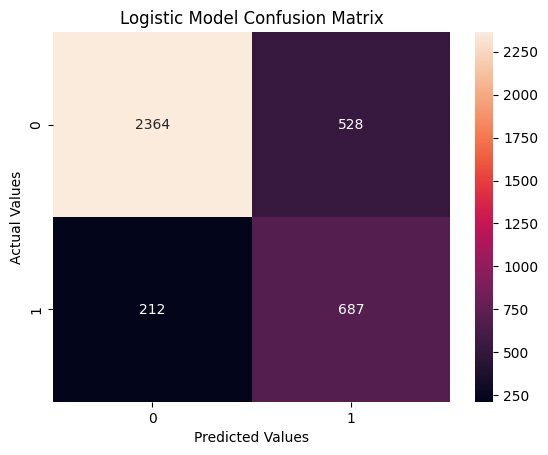

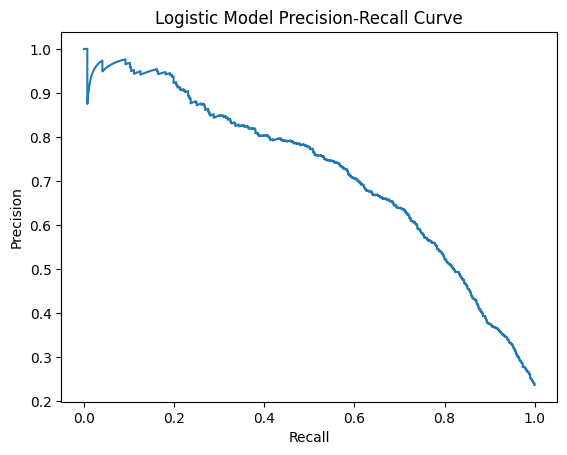

In [87]:
evaluate_model("Logistic smote Model", baseline_model_smote ,X_test, y_test)

In [88]:
rf_model_smote = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier())
])

rf_model_smote.fit(X_train_smote, y_train_smote)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', RandomForestClassifier())])

Random Forest Model Metrics:
Accuracy : 0.90
Precision : 0.82
Recall : 0.74
F1 : 0.78

Random Forest Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2892
         1.0       0.82      0.74      0.78       899

    accuracy                           0.90      3791
   macro avg       0.87      0.84      0.86      3791
weighted avg       0.90      0.90      0.90      3791



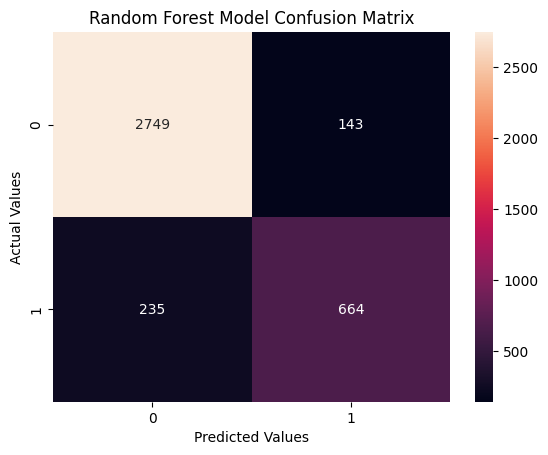

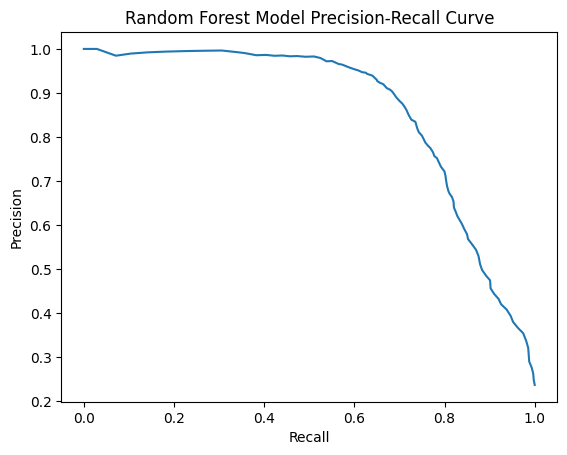

In [90]:
evaluate_model("Random Forest Model", rf_model_smote ,X_test, y_test)

In [91]:
xg_model_smote = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', XGBClassifier(learning_rate=0.1))
])

xg_model_smote.fit(X_train_smote, y_train_smote)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Model Metrics:
Accuracy : 0.91
Precision : 0.88
Recall : 0.73
F1 : 0.80

XGBoost Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      2892
         1.0       0.88      0.73      0.80       899

    accuracy                           0.91      3791
   macro avg       0.90      0.85      0.87      3791
weighted avg       0.91      0.91      0.91      3791



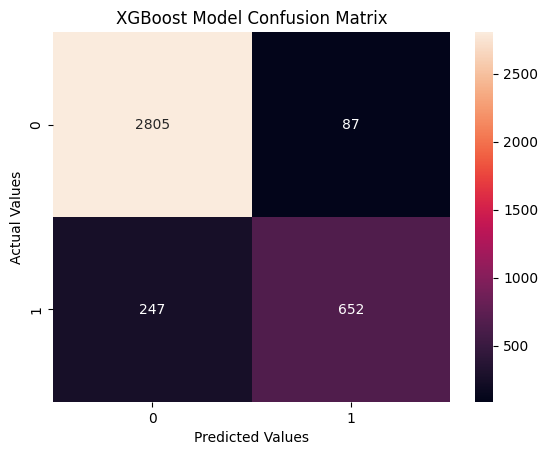

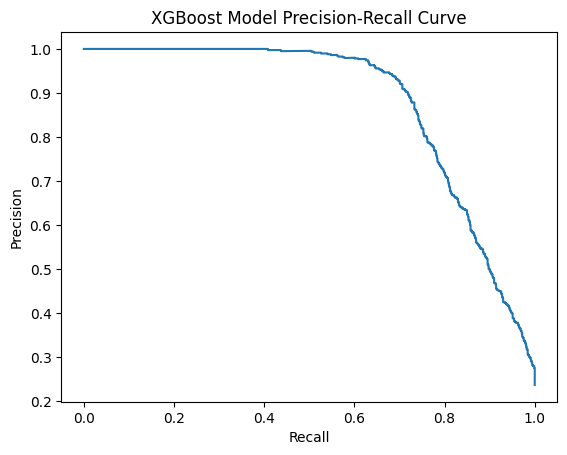

In [92]:
evaluate_model("XGBoost Model", xg_model_smote ,X_test, y_test)

## 10. Logistic Regression Hyperparameter Tuning
- Now we move to a stronger model, XGBoost.
- A model has many settings called hyperparameters.
- We search for the best combination of these settings.
- We use cross-validation while searching, so the result is reliable.

In [93]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [97]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_grid = {
    # Regularization strength
    "classifier__C": loguniform(1e-3, 100),

    # Type of regularization
    "classifier__penalty": ["l1", "l2"],

    # Optimization algorithm
    "classifier__solver": ["liblinear", "saga"],

    # Number of iterations
    "classifier__max_iter": [50, 100, 200],

    # Numerical convergence tolerance
    "classifier__tol": loguniform(1e-5, 1e-2)
}

In [98]:
random_search = RandomizedSearchCV(
    baseline_model,
    param_grid,
    n_iter=150,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'cb_person_cred_hist_length']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fi...
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fb3b9d57110>,
                                        'classifier__max_iter': [50, 100, 200],
                                        'classifier__penalty': ['l1', 'l2'],
                                        'classifier__solver': ['liblinear',
                                                               'saga'],
                                        'classifier__tol': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fb3b9cef230>},
                   scoring='recall', verbose=1)

In [101]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.82


In [ ]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.9374256499933686),
 'classifier__gamma': np.float64(2.391359792655321),
 'classifier__learning_rate': np.float64(0.1316690691287814),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 7,
 'classifier__n_estimators': 366,
 'classifier__subsample': np.float64(0.845303589935636)}

## 11. SHAP Interpretation — Global & Local
- SHAP helps us understand why the model makes a decision.
- It is a way of explaining a "black box" model.

In [102]:
#1. Install SHAP if not exists
!pip install shap
import shap

In [103]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
logistic_classifier = baseline_model.named_steps['classifier']

In [104]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = baseline_model.named_steps['preprocessor'].transform(X_test)

In [105]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = baseline_model.named_steps['preprocessor'].get_feature_names_out()

In [106]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [110]:
# 6. Create SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    logistic_classifier,
    X_test_df
)

In [111]:
#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-5.54108957e-02,  1.94414643e+00,  5.45420168e-02, ...,
        -3.34061225e-02,  0.00000000e+00, -1.21825746e-03],
       [-1.61390958e-03, -1.83547738e-01,  4.73952504e-03, ...,
        -3.34061225e-02,  0.00000000e+00, -1.21825746e-03],
       [ 1.32878556e-01, -4.23335679e+00, -4.50629668e-02, ...,
        -3.34061225e-02,  0.00000000e+00, -1.21825746e-03],
       ...,
       [-5.54108957e-02,  1.68001887e+00,  4.73952504e-03, ...,
        -3.34061225e-02,  0.00000000e+00,  7.48358151e-03],
       [-1.61390958e-03, -7.33813470e-01,  5.45420168e-02, ...,
        -3.34061225e-02,  0.00000000e+00, -1.21825746e-03],
       [-2.85124026e-02,  1.27693088e+00,  1.71901480e-02, ...,
        -3.34061225e-02,  0.00000000e+00, -1.21825746e-03]])

### Global explanation
- This shows which features matter most overall.
- It also shows if a feature increases or decreases risk.

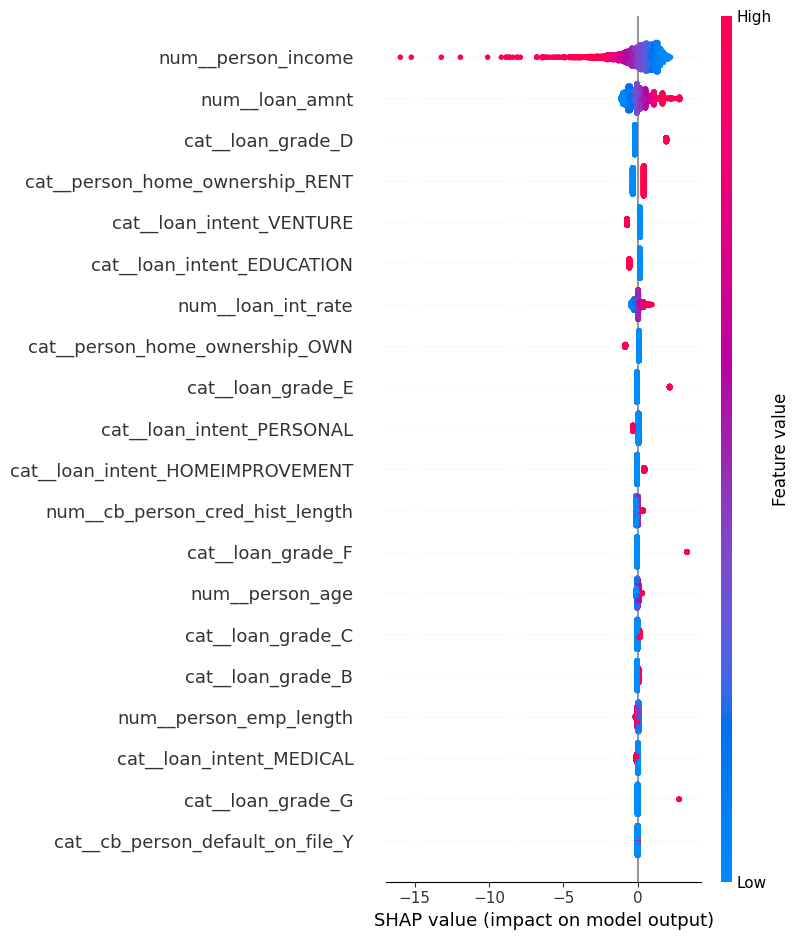

In [112]:
shap.summary_plot(shap_values, X_test_df)

### Local explanation
- This shows why one specific applicant got their score.
- It breaks the score down feature by feature.

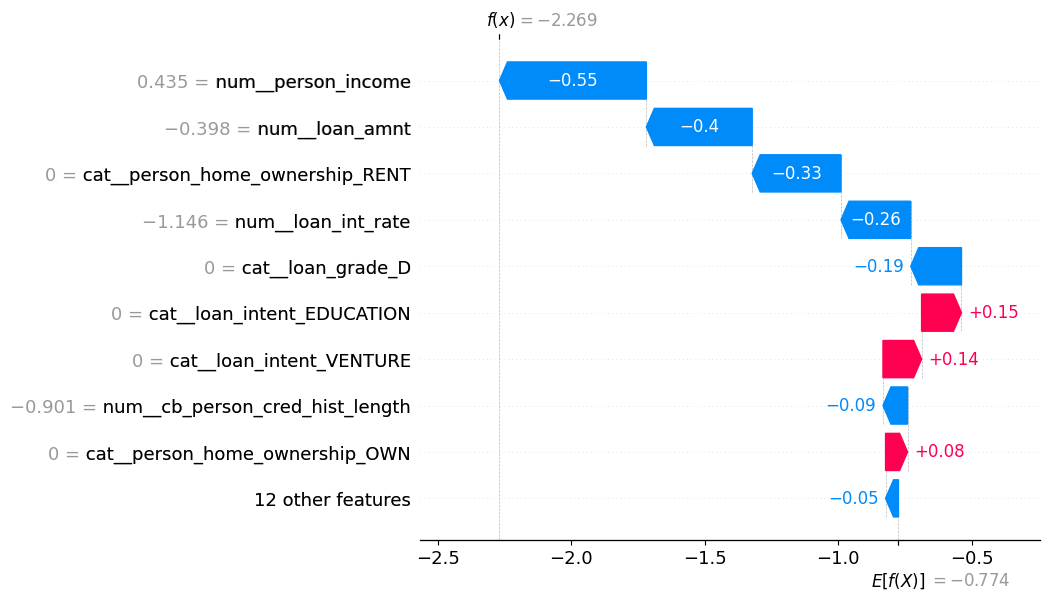

In [113]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

In [122]:
import numpy as np
import pandas as pd

importance = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': X_test_df.columns,
    'importance': importance
})

shap_importance = shap_importance.sort_values(
    'importance',
    ascending=False
)

shap_importance['rank'] = range(1, len(shap_importance) + 1)

print(shap_importance)

                             feature  importance  rank
1                 num__person_income    1.015509     1
3                     num__loan_amnt    0.605948     2
16                 cat__loan_grade_D    0.381921     3
8    cat__person_home_ownership_RENT    0.372026     4
13          cat__loan_intent_VENTURE    0.241403     5
9         cat__loan_intent_EDUCATION    0.241142     6
4                 num__loan_int_rate    0.208685     7
7     cat__person_home_ownership_OWN    0.136432     8
17                 cat__loan_grade_E    0.111090     9
12         cat__loan_intent_PERSONAL    0.099494    10
10  cat__loan_intent_HOMEIMPROVEMENT    0.076574    11
5    num__cb_person_cred_hist_length    0.061341    12
18                 cat__loan_grade_F    0.058450    13
0                    num__person_age    0.043398    14
15                 cat__loan_grade_C    0.040244    15
14                 cat__loan_grade_B    0.037149    16
2             num__person_emp_length    0.031254    17
11        

In [115]:
#Get predictions from the best performing Logistic model on the test set
y_pred = random_search.predict(X_test)

In [116]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [117]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [118]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 1117
False Negative : 158


In [123]:
def predict_default(model, borrower_data):
    """
    Predict whether a borrower will default.

    Parameters
    ----------
    model : trained sklearn Pipeline
        Your trained Logistic Regression pipeline.
    borrower_data : dict
        Borrower's features using the original column names.

    Returns
    -------
    prediction : int
        0 = No default
        1 = Default
    probability : float
        Predicted probability of default.
    """

    X = pd.DataFrame([borrower_data])

    probability = model.predict_proba(X)[0, 1]
    prediction = int(probability >= 0.5)

    return prediction, probability

In [124]:
borrower = {
    'person_age': 25,
    'person_income': 50000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 3,
    'loan_intent': 'PERSONAL',
    'loan_grade': 'B',
    'loan_amnt': 10000,
    'loan_int_rate': 10.5,
    'loan_percent_income': 0.20,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 4
}

prediction, probability = predict_default(
    baseline_model,
    borrower
)

print("Prediction:", prediction)
print("Default probability:", probability)

Prediction: 0
Default probability: 0.49737340662499513
